<a href="https://colab.research.google.com/github/Official-89/Parkinsons_Model_Training/blob/main/Parkinsons_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parkinson's Disease Prediction Using Speech Signals


## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from numpy import mean, std

## 2. Load and Explore the Dataset


In [ ]:
df = pd.read_csv('/content/MDVR_all_features.csv')

# Remove the voice ID column since it's just an identifier, not a feature
df.drop('voiceID', inplace=True, axis=1)

print("Dataset shape:", df.shape)
print()
print("Class distribution:")
print(df['label'].value_counts())
print()
df.head()


Dataset shape: (37, 25)

Class distribution:
label
0    21
1    16
Name: count, dtype: int64



,meanF0Hz,stdevF0Hz,HNR,localJitter,localabsoluteJitter,rapJitter,ppq5Jitter,localShimmer,localdbShimmer,apq3Shimmer,...,mfcc_feature4,mfcc_feature5,mfcc_feature6,mfcc_feature7,mfcc_feature8,mfcc_feature9,mfcc_feature10,mfcc_feature11,mfcc_feature12,label
0,180.433976,51.653057,13.292053,0.027039,0.000151,0.012019,0.013197,0.113439,1.124025,0.046161,...,36.622796,4.381283,-51.226759,-21.675977,-7.684882,2.750536,3.849808,8.752428,0.208220,0
1,190.751972,34.887596,11.243993,0.016118,0.000085,0.006764,0.007168,0.079053,0.740666,0.029396,...,22.481075,22.888370,-16.576583,-0.005128,-22.860485,-1.250413,-8.307896,-7.638449,0.425119,0
2,124.477366,26.621493,13.423983,0.026740,0.000216,0.010862,0.011512,0.102565,0.974095,0.039042,...,31.359476,33.517867,-34.057906,-12.091941,-11.613016,-3.418581,-15.054758,1.423258,7.775569,0
3,182.557207,39.933612,12.235210,0.020701,0.000114,0.008979,0.008983,0.080388,0.811653,0.025759,...,18.603944,8.521459,-22.354081,-10.347535,-16.455566,-18.876045,10.377634,3.105279,-2.436225,0
4,195.969796,41.446983,14.669165,0.015063,0.000077,0.005371,0.006017,0.082016,0.827343,0.029087,...,26.795330,16.121763,-45.669335,-11.787999,-14.445165,0.833958,3.394994,0.135964,-6.316675,0


In [ ]:
df.describe()

,meanF0Hz,stdevF0Hz,HNR,localJitter,localabsoluteJitter,rapJitter,ppq5Jitter,localShimmer,localdbShimmer,apq3Shimmer,...,mfcc_feature4,mfcc_feature5,mfcc_feature6,mfcc_feature7,mfcc_feature8,mfcc_feature9,mfcc_feature10,mfcc_feature11,mfcc_feature12,label
count,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,...,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,167.457574,40.580354,13.481044,0.023604,0.000151,0.010275,0.010958,0.096316,0.940552,0.036721,...,26.983006,24.534434,-14.658999,-2.344370,-12.186701,-3.743819,0.003344,-1.294651,1.061976,0.432432
std,30.826544,12.639763,1.689425,0.005694,0.000062,0.003032,0.002919,0.021066,0.173345,0.010148,...,12.726663,14.297257,15.035068,13.249363,11.363720,11.363840,9.653106,7.705090,8.945486,0.502247
min,99.176942,15.856715,10.195438,0.013899,0.000077,0.005279,0.005674,0.060868,0.629243,0.023605,...,-9.612589,-1.269567,-51.226759,-24.561546,-35.680011,-40.630948,-28.457065,-16.292199,-16.042029,0.000000
25%,139.689970,34.365179,12.332291,0.019678,0.000111,0.008344,0.009032,0.080560,0.810418,0.029396,...,20.603586,12.465326,-20.877052,-11.787999,-17.471027,-12.009368,-5.214899,-6.654626,-5.702192,0.000000
50%,173.417455,39.933612,13.388906,0.022659,0.000131,0.009854,0.010480,0.095878,0.963974,0.035746,...,25.994576,25.461889,-15.199401,-1.961568,-13.068323,0.028050,0.381197,-1.466902,1.554965,0.000000
75%,190.751972,46.792915,14.583647,0.027164,0.000189,0.012019,0.013001,0.105540,1.005431,0.040549,...,36.367023,35.371636,-7.150892,5.476300,-3.977438,5.188163,4.421726,3.519430,8.576886,1.000000
max,214.216909,81.862069,16.854876,0.038871,0.000332,0.017499,0.017930,0.179428,1.531849,0.070886,...,51.931076,50.608532,36.373886,34.894468,19.013661,16.090623,19.289492,20.126116,17.294757,1.000000


## 3. BoxPlots for Data Analysis


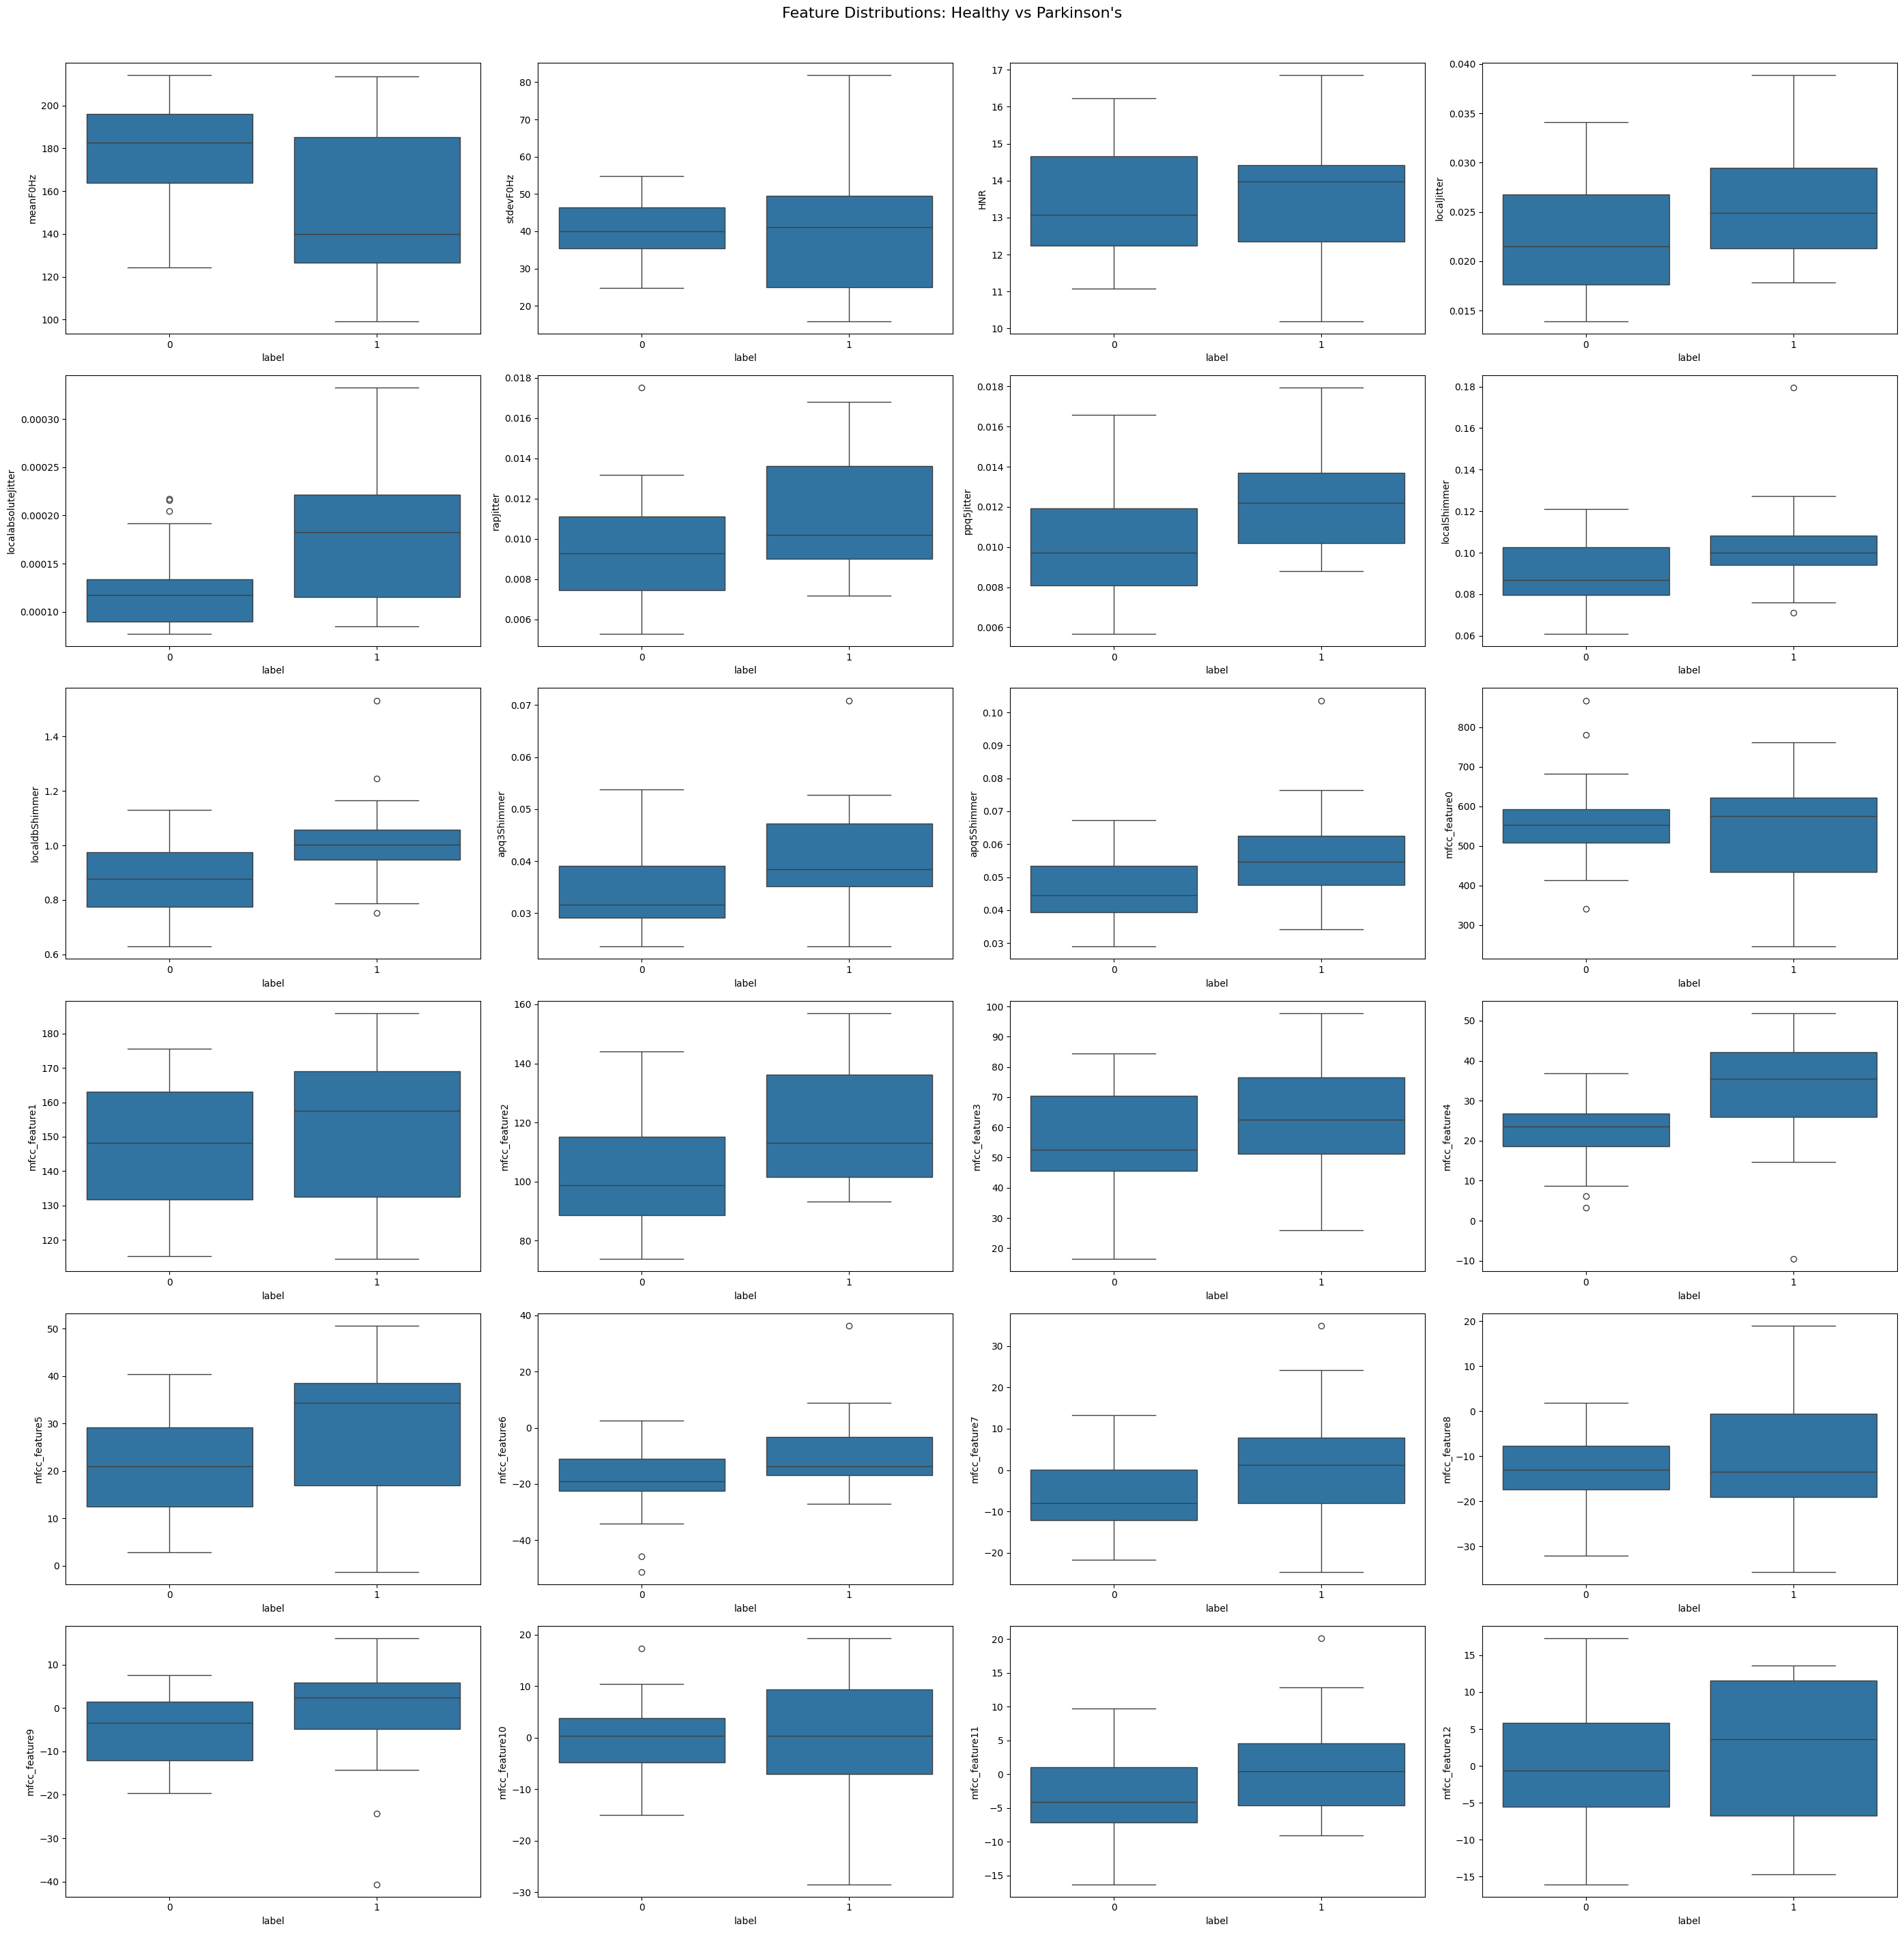

In [ ]:
cols = df.columns.drop('label')
fig, ax = plt.subplots(6, 4, figsize=(28, 28))

for i, col in enumerate(cols[:24]):  # only show first 24 features
    sns.boxplot(y=col, x='label', data=df, ax=ax[i // 4, i % 4])

plt.suptitle("Feature Distributions: Healthy vs Parkinson's", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## 4. Prepare Data for Modelling

1. Separate the features (X) from the labels (y)
2. Split into training and test sets (70% train, 30% test)
3. Scale the features using MinMaxScaler so all values are between 0 and 1 — this helps models like KNN and SVM perform better


In [ ]:
# Separate features (X) and labels (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (25, 24)
Test set size: (12, 24)


In [ ]:
sc = MinMaxScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:

def evaluate_model(model_name, y_true, y_pred):
    """Prints accuracy, classification report, and confusion matrix for a model."""
    cm = confusion_matrix(y_true, y_pred)
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum() * 100

    print(f"=== {model_name} ===")
    print(f"Accuracy: {accuracy:.2f}%")
    print()
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_true, y_pred))
    print("Confusion Matrix:")
    print(cm)
    print()
    return accuracy


## 5. K-Nearest Neighbours (KNN)

KNN classifies a new sample by looking at the k closest samples in the training set and using a majority vote. It's simple but effective.

### 5.1 Baseline KNN (default settings)


In [ ]:
# Train KNN with default-ish settings
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

evaluate_model("KNN (n_neighbors=10)", y_test, y_pred_knn)


=== KNN (n_neighbors=10) ===
Accuracy: 58.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.67      0.33      0.44         6

    accuracy                           0.58        12
   macro avg       0.61      0.58      0.56        12
weighted avg       0.61      0.58      0.56        12

ROC AUC Score: 0.5833333333333334
Confusion Matrix:
[[5 1]
 [4 2]]



np.float64(58.333333333333336)

### 5.2 KNN with Hyperparameter Tuning|

In [ ]:
# Define the hyperparameters to try
knn_params = {
    'n_neighbors': list(range(1, 20)),
    'p': [1, 2],           # 1 = Manhattan distance, 2 = Euclidean distance
    'leaf_size': list(range(1, 30))
}

# GridSearchCV tries all combinations and picks the best
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=10)
knn_grid.fit(X_train_scaled, y_train)

print("Best KNN parameters:", knn_grid.best_params_)
print("Best CV score:", knn_grid.best_score_)


Best KNN parameters: {'leaf_size': 1, 'n_neighbors': 1, 'p': 1}
Best CV score: 0.7


### 5.3 KNN with Best Parameters

In [ ]:
# Train KNN using the best parameters found above
best_knn = KNeighborsClassifier(n_neighbors=9, p=1, leaf_size=1)
best_knn.fit(X_train_scaled, y_train)
y_pred_knn_best = best_knn.predict(X_test_scaled)

evaluate_model("KNN (tuned)", y_test, y_pred_knn_best)


=== KNN (tuned) ===
Accuracy: 66.67%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         6
           1       0.67      0.67      0.67         6

    accuracy                           0.67        12
   macro avg       0.67      0.67      0.67        12
weighted avg       0.67      0.67      0.67        12

ROC AUC Score: 0.6666666666666667
Confusion Matrix:
[[4 2]
 [2 4]]



np.float64(66.66666666666666)

### 5.4 KNN — Leave-One-Out Cross Validation

Leave-one-out cross validation is where we use one sample as the test set and train on everything else. This is repeated for every sample in the dataset. It gives a reliable estimate of how well the model generalises.

In [ ]:
# Scale the full dataset for cross-validation
X_all = df.iloc[:, :-1].values
y_all = df.iloc[:, -1].values
X_all_scaled = sc.fit_transform(X_all)

# Leave-one-out: n_splits = number of samples
loo = KFold(n_splits=len(X_all))

best_knn_cv = KNeighborsClassifier(n_neighbors=9, p=1, leaf_size=1)
loo_scores = cross_val_score(best_knn_cv, X_all_scaled, y_all, scoring='accuracy', cv=loo)

print("KNN Leave-One-Out Cross Validation")
print(f"Mean Accuracy: {mean(loo_scores)*100:.2f}%  |  Std: {std(loo_scores)*100:.2f}%")


KNN Leave-One-Out Cross Validation
Mean Accuracy: 62.16%  |  Std: 48.50%


## 6. Support Vector Machine (SVM)|

### 6.1 Baseline SVM


In [ ]:
svm = SVC()
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

evaluate_model("SVM (default)", y_test, y_pred_svm)


=== SVM (default) ===
Accuracy: 66.67%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         6
           1       0.67      0.67      0.67         6

    accuracy                           0.67        12
   macro avg       0.67      0.67      0.67        12
weighted avg       0.67      0.67      0.67        12

ROC AUC Score: 0.6666666666666667
Confusion Matrix:
[[4 2]
 [2 4]]



np.float64(66.66666666666666)

### 6.2 SVM with Hyperparameter Tuning

In [ ]:
svm_params = {
    'C': [0.1, 1, 10, 100, 1000],       # controls the penalty for misclassification
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],  # controls the reach of each training example
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(SVC(), svm_params, refit=True)
svm_grid.fit(X_train_scaled, y_train)

print("Best SVM parameters:", svm_grid.best_params_)
print("Best CV score:", svm_grid.best_score_)


Best SVM parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Best CV score: 0.6400000000000001


### 6.3 SVM with Best Parameters

In [ ]:
best_svm = SVC(C=10, gamma=0.1, kernel='rbf')
best_svm.fit(X_train_scaled, y_train)
y_pred_svm_best = best_svm.predict(X_test_scaled)

evaluate_model("SVM (tuned)", y_test, y_pred_svm_best)


=== SVM (tuned) ===
Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.50      0.50      0.50         6

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.50        12
weighted avg       0.50      0.50      0.50        12

ROC AUC Score: 0.5
Confusion Matrix:
[[3 3]
 [3 3]]



np.float64(50.0)

### 6.4 SVM — Leave-One-Out Cross Validation

In [ ]:
best_svm_cv = SVC(C=10, gamma=0.1, kernel='rbf')
loo_scores_svm = cross_val_score(best_svm_cv, X_all_scaled, y_all, scoring='accuracy', cv=loo)

print("SVM Leave-One-Out Cross Validation")
print(f"Mean Accuracy: {mean(loo_scores_svm)*100:.2f}%  |  Std: {std(loo_scores_svm)*100:.2f}%")


SVM Leave-One-Out Cross Validation
Mean Accuracy: 67.57%  |  Std: 46.81%


## 7. Results Summary

In [ ]:
results = {
    'KNN (tuned)': mean(loo_scores) * 100,
    'SVM (tuned)': mean(loo_scores_svm) * 100,
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'LOO Accuracy (%)'])
results_df = results_df.sort_values('LOO Accuracy (%)', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


      Model  LOO Accuracy (%)
SVM (tuned)         67.567568
KNN (tuned)         62.162162


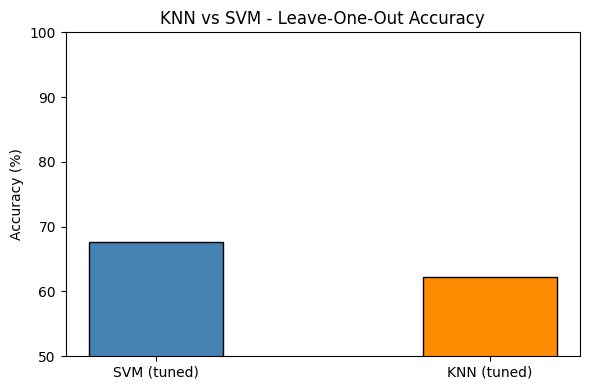

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(results_df['Model'], results_df['LOO Accuracy (%)'],
        color=['steelblue', 'darkorange'], edgecolor='black', width=0.4)
plt.ylabel('Accuracy (%)')
plt.title('KNN vs SVM - Leave-One-Out Accuracy')
plt.ylim(50, 100)
plt.tight_layout()
plt.show()
so

## 8. Conclusions

In this project, I compared two machine learning models — KNN and SVM — for predicting Parkinson's disease from acoustic speech features.

- **KNN** classifies by finding the most similar samples in the training set. It performed well after tuning the number of neighbours and distance metric.
- **SVM** finds the optimal decision boundary between the two classes using an RBF kernel. It tends to be more robust on smaller datasets and handles overlapping classes well.
- **Leave-one-out cross validation** was used because the dataset is small — it gives the most honest estimate of how each model would perform on new, unseen data.
- Both models were tuned using **GridSearchCV**, which systematically tests different hyperparameter combinations to find the best configuration.

Overall, voice-based features like jitter, shimmer, and HNR show clear differences between healthy controls and Parkinson's patients, making this a strong signal for machine learning classification.


In [ ]:
import joblib


joblib.dump(best_svm, 'parkinsons_model.pkl')


joblib.dump(sc, 'scaler.pkl')

print("Files exported successfully! Download them from the sidebar.")

Files exported successfully! Download them from the sidebar.
